In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [58]:
file_path = r"C:\Users\Akash Mundari\Videos\Data Engineering\ML Basics\BlinkIT Grocery Data Excel.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="BlinkIT Grocery Data"
)

df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [59]:
df.shape

(8523, 12)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [61]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [62]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

Item Weight                  1463
Item Fat Content                0
Item Type                       0
Item Identifier                 0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Size                     0
Outlet Location Type            0
Outlet Type                     0
Item Visibility                 0
Sales                           0
Rating                          0
dtype: int64

In [63]:
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_summary

,Missing Count,Missing %
Item Weight,1463,17.165317
Item Fat Content,0,0.000000
Item Type,0,0.000000
Item Identifier,0,0.000000
Outlet Establishment Year,0,0.000000
Outlet Identifier,0,0.000000
Outlet Size,0,0.000000
Outlet Location Type,0,0.000000
Outlet Type,0,0.000000
Item Visibility,0,0.000000


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df["Item Fat Content"].value_counts()

Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [66]:
## Standardizing Fat Content

In [67]:
df["Item Fat Content"] = df["Item Fat Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

In [68]:
df["Item Fat Content"].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [69]:
print("Zero visibility:", (df["Item Visibility"] == 0).sum())
print("Negative sales:", (df["Sales"] < 0).sum())
print("Negative weight:", (df["Item Weight"] < 0).sum())

Zero visibility: 526
Negative sales: 0
Negative weight: 0


In [70]:
## Inspecting the medians

In [71]:
weight_medians = (
    df.groupby("Item Type")["Item Weight"]
      .median()
      .sort_values()
)

weight_medians

Item Type
Hard Drinks              10.100
Breads                   10.600
Breakfast                10.695
Baking Goods             11.650
Seafood                  11.650
Soft Drinks              11.800
Canned                   12.150
Health and Hygiene       12.150
Meat                     12.350
Frozen Foods             12.850
Fruits and Vegetables    13.100
Snack Foods              13.150
Household                13.150
Starchy Foods            13.175
Dairy                    13.350
Others                   14.500
Name: Item Weight, dtype: float64

In [74]:
df["Item Weight"] = (
    df.groupby("Item Type")["Item Weight"]
      .transform(lambda x: x.fillna(x.median()))
)

df["Item Weight"]

0       15.10
1       11.80
2       13.85
3       12.15
4       19.60
        ...  
8518    12.15
8519    13.15
8520    11.80
8521    13.35
8522    13.15
Name: Item Weight, Length: 8523, dtype: float64

In [17]:
df["Item Weight"].isnull().sum()

np.int64(0)

In [18]:
## Handling Zero item visibility

In [19]:
df[df["Item Visibility"] == 0][
    ["Item Type", "Item Visibility", "Sales"]
].head(10)

,Item Type,Item Visibility,Sales
20,Fruits and Vegetables,0.0,60.2194
59,Fruits and Vegetables,0.0,111.9518
79,Dairy,0.0,194.2794
98,Health and Hygiene,0.0,123.4730
113,Frozen Foods,0.0,83.7566
150,Dairy,0.0,171.5764
151,Health and Hygiene,0.0,39.1506
179,Soft Drinks,0.0,189.8530
197,Health and Hygiene,0.0,149.2708
221,Snack Foods,0.0,186.4898


In [20]:
visibility_medians = (
    df[df["Item Visibility"] > 0]
    .groupby("Item Type")["Item Visibility"]
    .median()
)

visibility_medians

Item Type
Baking Goods             0.062343
Breads                   0.058642
Breakfast                0.069089
Canned                   0.053434
Dairy                    0.067584
Frozen Foods             0.063080
Fruits and Vegetables    0.058778
Hard Drinks              0.064325
Health and Hygiene       0.046559
Household                0.049017
Meat                     0.049753
Others                   0.048677
Seafood                  0.055936
Snack Foods              0.057584
Soft Drinks              0.053590
Starchy Foods            0.062276
Name: Item Visibility, dtype: float64

In [21]:
df["Item Visibility"] = df.apply(
    lambda row: (
        visibility_medians[row["Item Type"]]
        if row["Item Visibility"] == 0
        else row["Item Visibility"]
    ),
    axis=1
)

In [22]:
(df["Item Visibility"] == 0).sum()

np.int64(0)

In [23]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nZero visibility:", (df["Item Visibility"] == 0).sum())

Shape: (8523, 12)

Missing values:
Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
dtype: int64

Duplicates: 0

Zero visibility: 0


In [24]:
## Sales by Outlet type

In [25]:
sales_by_outlet = (
    df.groupby("Outlet Type")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_outlet

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64

In [26]:
## Sales by Location tier

In [27]:
sales_by_tier = (
    df.groupby("Outlet Location Type")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_tier

Outlet Location Type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: Sales, dtype: float64

In [28]:
## Sales by Item type

In [29]:
sales_by_item = (
    df.groupby("Item Type")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_item

Item Type
Fruits and Vegetables    178124.0810
Snack Foods              175433.9224
Household                135976.5254
Frozen Foods             118558.8814
Dairy                    101276.4616
Canned                    90706.7290
Baking Goods              81894.7364
Health and Hygiene        68025.8388
Meat                      59449.8638
Soft Drinks               58514.1670
Breads                    35379.1198
Hard Drinks               29334.6806
Others                    22451.8916
Starchy Foods             21880.0274
Breakfast                 15596.6966
Seafood                    9077.8700
Name: Sales, dtype: float64

In [30]:
rating_by_outlet = (
    df.groupby("Outlet Type")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

rating_by_outlet

Outlet Type
Grocery Store        3.985873
Supermarket Type2    3.971228
Supermarket Type1    3.963242
Supermarket Type3    3.952941
Name: Rating, dtype: float64

In [31]:
outlet_sales = (
    df.groupby("Outlet Type")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

outlet_sales

Outlet Type
Supermarket Type1    787549.8928
Grocery Store        151939.1490
Supermarket Type2    131477.7764
Supermarket Type3    130714.6746
Name: Sales, dtype: float64

In [32]:
total_sales = df["Sales"].sum()

supermarket1_sales = outlet_sales["Supermarket Type1"]

share = supermarket1_sales / total_sales * 100

print(f"Supermarket Type1 sales share: {share:.2f}%")

Supermarket Type1 sales share: 65.54%


In [33]:
## Tier analysis

In [34]:
tier_sales = (
    df.groupby("Outlet Location Type")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

tier_sales

Outlet Location Type
Tier 3    472133.0332
Tier 2    393150.6476
Tier 1    336397.8120
Name: Sales, dtype: float64

In [35]:
tier1 = tier_sales["Tier 1"]
tier3 = tier_sales["Tier 3"]

difference_pct = (tier3 - tier1) / tier1 * 100

print(f"Tier 3 vs Tier 1 sales difference: {difference_pct:.2f}%")

Tier 3 vs Tier 1 sales difference: 40.35%


In [36]:
## Visualizations

In [37]:
## Sales by outlet type

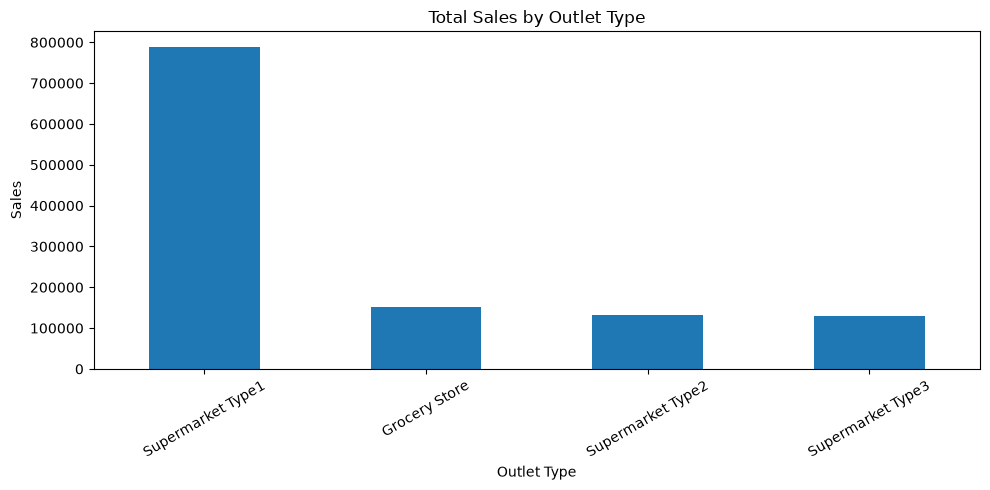

In [38]:
plt.figure(figsize=(10, 5))

sales_by_outlet.plot(kind="bar")

plt.title("Total Sales by Outlet Type")
plt.xlabel("Outlet Type")
plt.ylabel("Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [39]:
## Sales by location tier

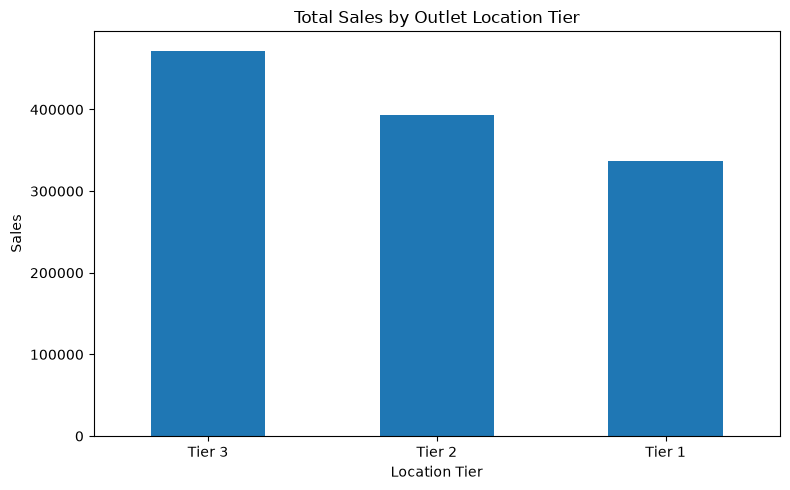

In [40]:
plt.figure(figsize=(8, 5))

tier_sales.plot(kind="bar")

plt.title("Total Sales by Outlet Location Tier")
plt.xlabel("Location Tier")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
## Sales by item type

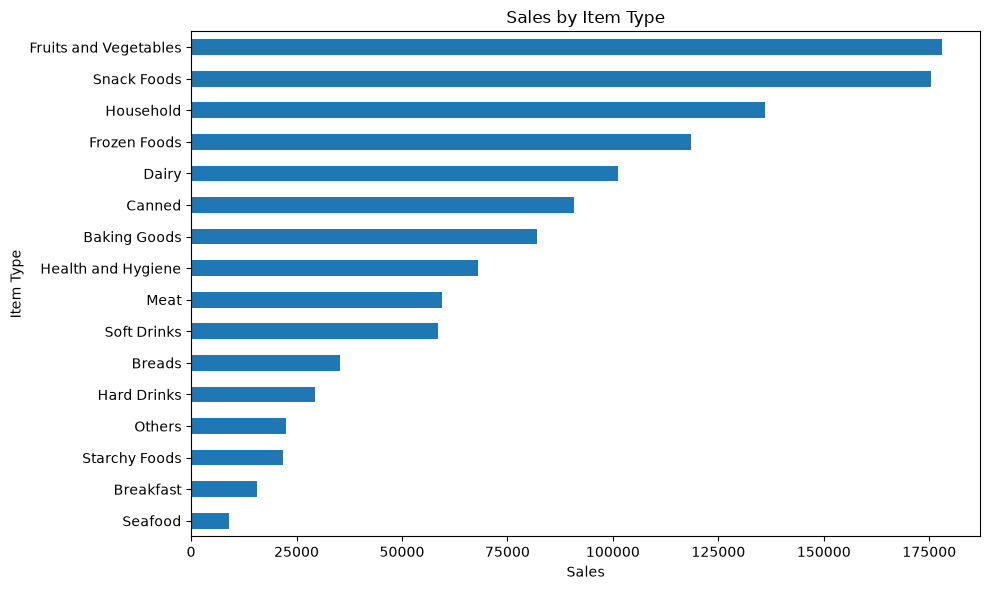

In [42]:
plt.figure(figsize=(10, 6))

sales_by_item.sort_values().plot(kind="barh")

plt.title("Sales by Item Type")
plt.xlabel("Sales")
plt.ylabel("Item Type")
plt.tight_layout()
plt.show()

In [43]:
### Correlation analysis

In [44]:
numeric_cols = [
    "Outlet Establishment Year",
    "Item Visibility",
    "Item Weight",
    "Sales",
    "Rating"
]

correlation = df[numeric_cols].corr()

correlation["Sales"].sort_values(ascending=False)

Sales                        1.000000
Item Weight                  0.026537
Rating                       0.011329
Outlet Establishment Year   -0.000654
Item Visibility             -0.004770
Name: Sales, dtype: float64

In [45]:
model_df = df.drop(
    columns=["Item Identifier", "Outlet Identifier"]
)

X = model_df.drop(columns=["Sales"])
y = model_df["Sales"]

In [46]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical:", categorical_features)
print("\nNumerical:", numerical_features)

Categorical: ['Item Fat Content', 'Item Type', 'Outlet Location Type', 'Outlet Size', 'Outlet Type']

Numerical: ['Outlet Establishment Year', 'Item Visibility', 'Item Weight', 'Rating']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 6818
Testing rows: 1705


In [48]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [49]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [50]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [51]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [52]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


results = pd.DataFrame([
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    ),
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_pred
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
])

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Random Forest,31.853978,42.825625,0.537024
0,Linear Regression,52.331889,62.445292,0.015649
1,Ridge Regression,52.332891,62.445685,0.015636


In [53]:
## Feature importance from Random Forest

In [54]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = pd.Series(
    rf_estimator.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance.head(15)

numeric__Item Visibility                        0.324446
numeric__Item Weight                            0.278339
numeric__Rating                                 0.076125
numeric__Outlet Establishment Year              0.029131
categorical__Item Type_Dairy                    0.021803
categorical__Item Type_Frozen Foods             0.019528
categorical__Item Type_Fruits and Vegetables    0.019459
categorical__Item Type_Snack Foods              0.019385
categorical__Item Fat Content_Low Fat           0.018644
categorical__Item Type_Canned                   0.017632
categorical__Item Fat Content_Regular           0.017625
categorical__Item Type_Household                0.017229
categorical__Outlet Type_Grocery Store          0.011771
categorical__Item Type_Meat                     0.010885
categorical__Item Type_Soft Drinks              0.010697
dtype: float64

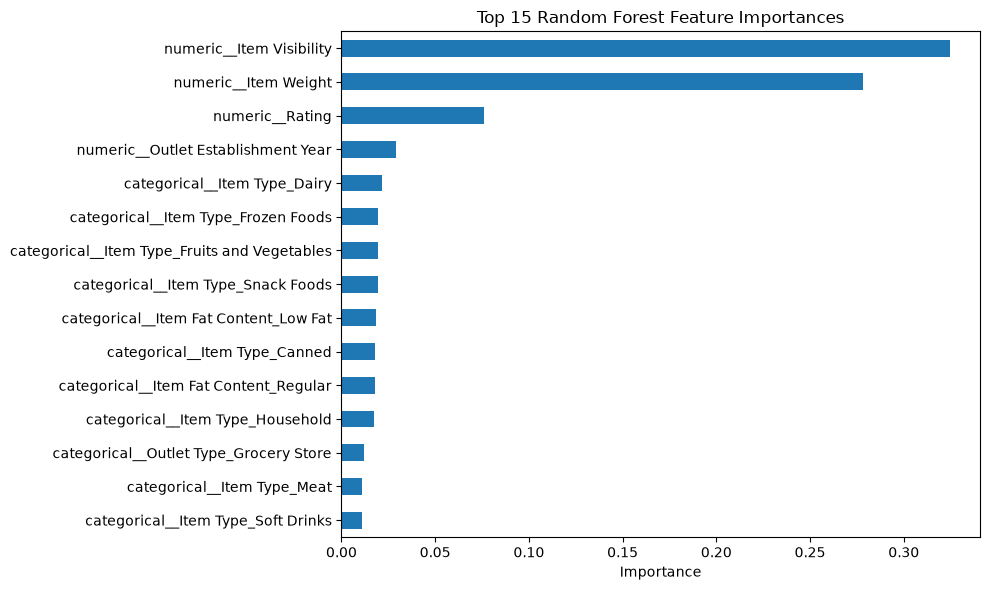

In [55]:
plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [56]:
df.to_csv(
    "blinkit_cleaned_data.csv",
    index=False
)